In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

print("Libraries loaded!")


Libraries loaded!


In [2]:
df = pd.read_csv('data/cleaned_retail.csv', parse_dates=['InvoiceDate'])
rfm = pd.read_csv('data/rfm_segments.csv')

df = df.merge(rfm[['Customer ID','Segment_Name']], on='Customer ID')

print("Shape:", df.shape)
df.head()

Shape: (407664, 10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Segment_Name
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Lost Customers
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Lost Customers
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Lost Customers
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Lost Customers
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Lost Customers


In [3]:

champions_df = df[df['Segment_Name'] == 'Champions'].copy()

weekly = (champions_df
          .resample('W', on='InvoiceDate')['Revenue']
          .sum()
          .reset_index())
weekly.columns = ['ds', 'y']

print("Weekly shape:", weekly.shape)
print(weekly.head())

Weekly shape: (54, 2)
          ds         y
0 2009-12-06  50053.76
1 2009-12-13  29829.78
2 2009-12-20  47886.61
3 2009-12-27  12685.02
4 2010-01-03      0.00


In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np


weekly_clean = weekly[weekly['y'] > 0].copy()
weekly_clean['week_num'] = range(len(weekly_clean))


X = weekly_clean[['week_num']]
y = weekly_clean['y']

model = LinearRegression()
model.fit(X, y)


future_weeks = pd.DataFrame({'week_num': range(len(weekly_clean), len(weekly_clean)+12)})
future_weeks['ds'] = pd.date_range(start=weekly_clean['ds'].max(), periods=12, freq='W')
future_weeks['yhat'] = model.predict(future_weeks[['week_num']])

print("Forecast done!")
print(future_weeks[['ds','yhat']])

Forecast done!
           ds          yhat
0  2010-12-12  25232.154971
1  2010-12-19  25148.006231
2  2010-12-26  25063.857492
3  2011-01-02  24979.708752
4  2011-01-09  24895.560012
5  2011-01-16  24811.411272
6  2011-01-23  24727.262533
7  2011-01-30  24643.113793
8  2011-02-06  24558.965053
9  2011-02-13  24474.816313
10 2011-02-20  24390.667574
11 2011-02-27  24306.518834


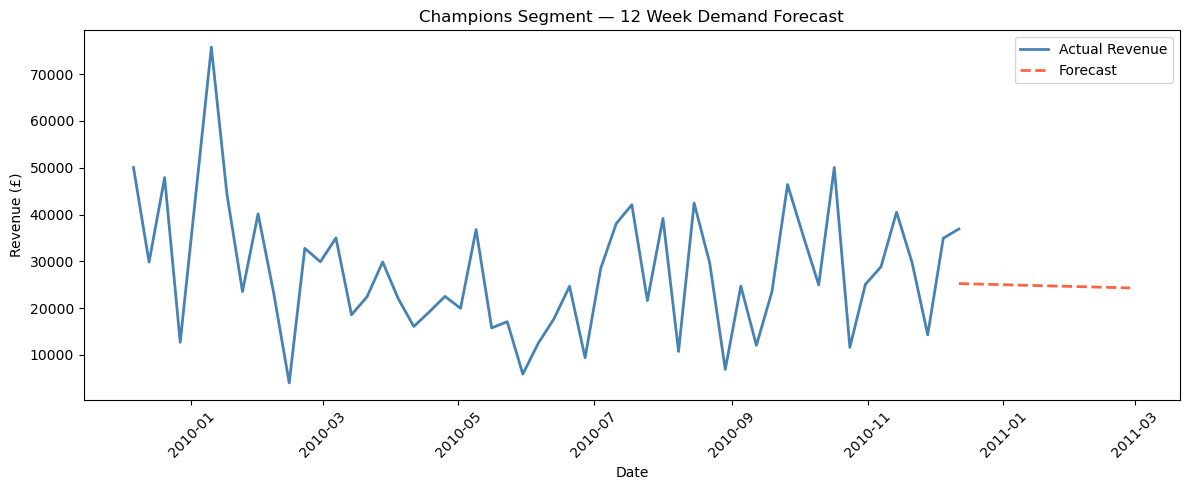

Chart saved!


In [5]:
plt.figure(figsize=(12,5))


plt.plot(weekly_clean['ds'], weekly_clean['y'], 
         label='Actual Revenue', color='steelblue', linewidth=2)


plt.plot(future_weeks['ds'], future_weeks['yhat'], 
         label='Forecast', color='tomato', linewidth=2, linestyle='--')

plt.title('Champions Segment — 12 Week Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/forecast.png', bbox_inches='tight')
plt.show()
print("Chart saved!")

In [6]:
future_weeks.to_csv('data/forecast_champions.csv', index=False)
print("Forecast data saved!")

Forecast data saved!
